In [28]:
# sphinx_gallery_thumbnail_number = 2

import matplotlib.pyplot as plt
import numpy as np
import emd

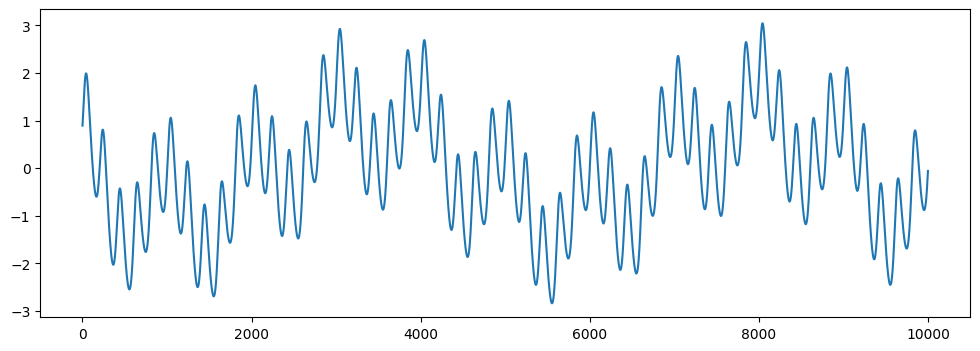

In [29]:
sample_rate = 1000
seconds = 10
num_samples = sample_rate*seconds

time_vect = np.linspace(0, seconds, num_samples)

freq = 5

# Change extent of deformation from sinusoidal shape [-1 to 1]
nonlinearity_deg = 0.25

# Change left-right skew of deformation [-pi to pi]
nonlinearity_phi = -np.pi/4

# Compute the signal

# Create a non-linear oscillation
x = emd.simulate.abreu2010(freq, nonlinearity_deg, nonlinearity_phi, sample_rate, seconds)

x += np.cos(2 * np.pi * 1 * time_vect)        # Add a simple 1Hz sinusoid
x -= np.sin(2 * np.pi * 2.2e-1 * time_vect)   # Add part of a very slow cycle as a trend

# Visualise the time-series for analysis
plt.figure(figsize=(12, 4))
plt.plot(x)

Try changing the values of nonlinearity_deg and nonlinearity_phi to create different non-sinusoidal waveform shapes.

Next, we can then estimate the IMFs for the signal:

In [30]:
imf = emd.sift.sift(x)
print(imf.shape)
print(imf)

(10000, 4)
[[ 0.0604299   1.06368973  0.3991291  -0.62888515]
 [ 0.09271927  1.06645217  0.39911897 -0.62884023]
 [ 0.1254919   1.06915559  0.39910608 -0.62879502]
 ...
 [-0.15340796  0.83782711 -0.91909558  0.10736551]
 [-0.11636577  0.83572033 -0.91900226  0.10738553]
 [-0.07876292  0.83357032 -0.91890586  0.10740553]]


and, from the IMFs, compute the instantaneous frequency, phase and amplitude using the Normalised Hilbert Transform Method:

In [31]:
IP, IF, IA = emd.spectra.frequency_transform(imf, sample_rate, 'hilbert')

From the instantaneous frequency and amplitude, we can compute the Hilbert-Huang spectrum:

In [32]:
# Define frequency range (low_freq, high_freq, nsteps, spacing)
freq_range = (0.1, 10, 80, 'log')
f, hht = emd.spectra.hilberthuang(IF, IA, freq_range, sum_time=False)

## Visualising the results
we can now plot some summary information, first the IMFs:

<Axes: xlabel='Time (samples)'>

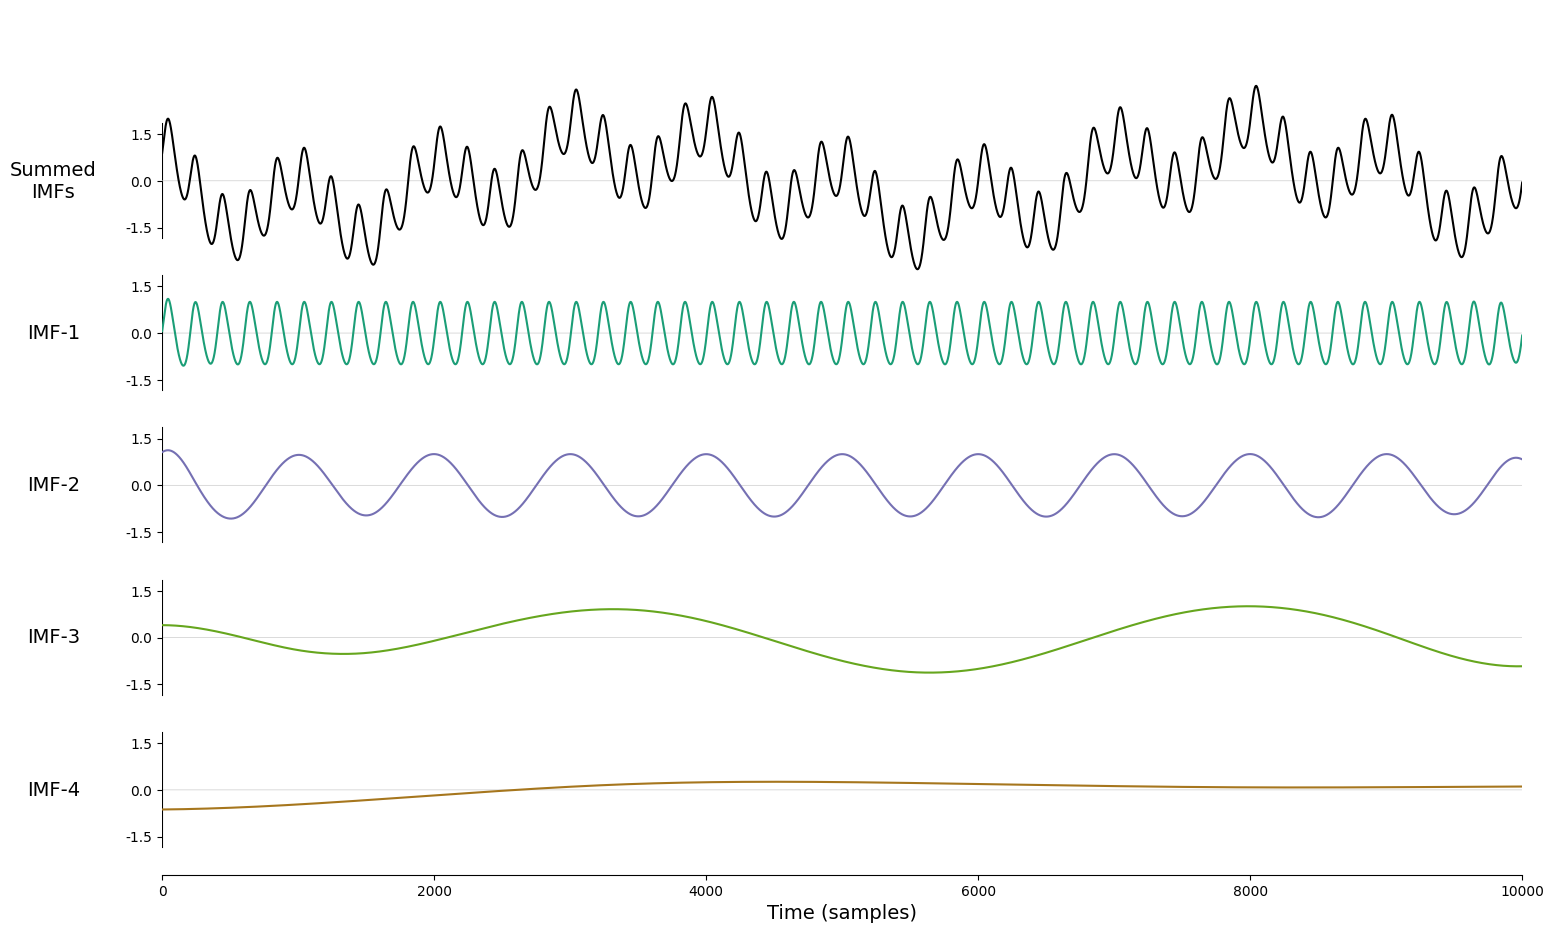

In [33]:
emd.plotting.plot_imfs(imf)

and now the Hilbert-Huang transform of this decomposition

<Axes: title={'center': 'Hilbert-Huang Transform'}, xlabel='Time', ylabel='Frequency'>

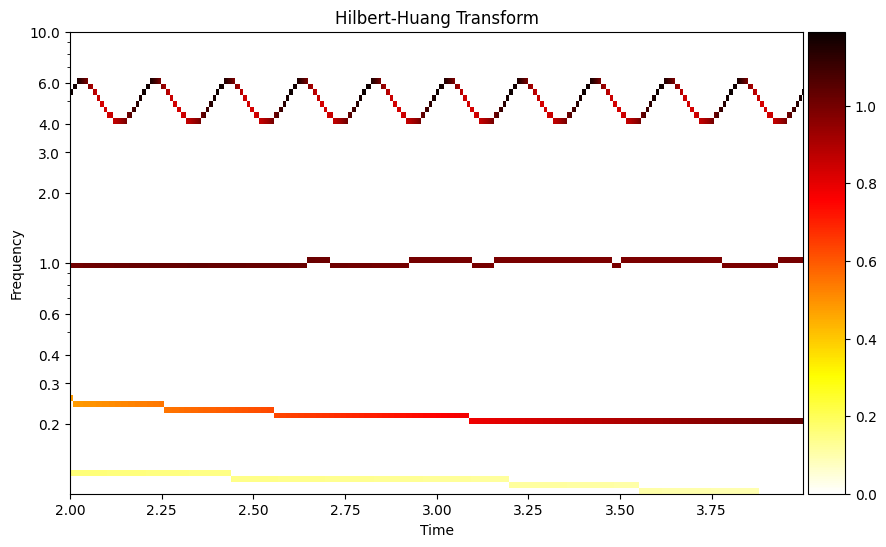

In [34]:
fig = plt.figure(figsize=(10, 6))
emd.plotting.plot_hilberthuang(hht, time_vect, f,
                               time_lims=(2, 4), freq_lims=(0.1, 15),
                               fig=fig, log_y=True)

## Why use EMD?
The motivations behind the Empirical Mode Demposition are straightforward but sometimes get lost in a relatively complicated and technical literature. This tutorial presents a quick summary of what EMD could add to your analysis and what issues it can help to solve.

### Frequency spectra of dynamic and non-sinusoidal signals
A core challenge in signal processing is finding an intuitive representation of the frequency content of complicated and dynamic signals. The most common approach is to use methods based on the Fourier-transform - in which we represent a signal with a set of sinusoidal basis functions. This is a very powerful and flexible approach but has some short-comings when working with dynamic or non-sinusoidal signals.

Let’s take a look at an example. Here we make two oscillatory signals - one with a sinusoidal waveform and one with a non-linearity.

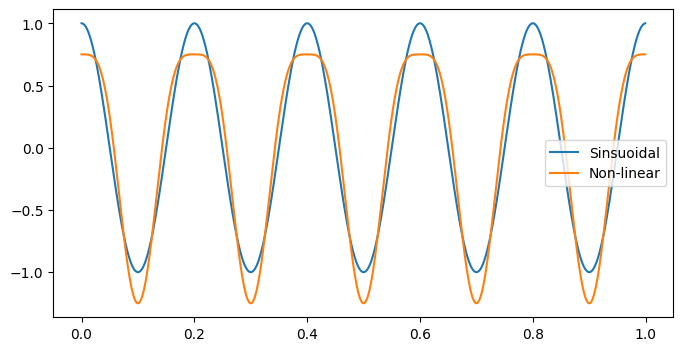

In [35]:
import emd
import numpy as np
from scipy import signal, ndimage
import matplotlib.pyplot as plt

sample_rate = 1000
seconds = 10
num_samples = sample_rate*seconds

time_vect = np.linspace(0, seconds, num_samples)

freq = 5

# Sinusoidal signal
x = np.cos(2*np.pi*freq*time_vect)

# Non-linear signal
y = np.cos(2*np.pi*freq*time_vect) + 0.25*np.cos(2*np.pi*freq*2*time_vect-np.pi)

# Quick summary figure
plt.figure(figsize=(8, 4))
plt.plot(time_vect[:sample_rate], x[:sample_rate])
plt.plot(time_vect[:sample_rate], y[:sample_rate])
plt.legend(['Sinsuoidal', 'Non-linear'])

# sphinx_gallery_thumbnail_number = 2

We can see that our non-linear signal has a wider trough and a sharper peak than the sinusoid - many natural signals might have oscillatory features like this. Unfortunately, the Fourier transform has to use multiple components to represent this oscillation as its basis set fixed and unchanging over time.

As an illustration, lets compute a fast-Fourier transform on our two signals

Text(0, 0.5, 'Power')

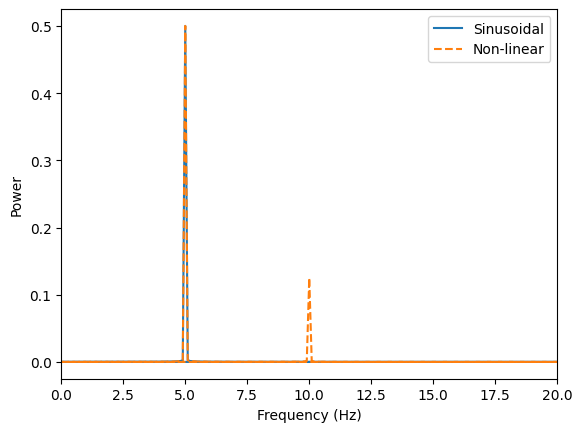

In [36]:
pxx = np.fft.fft(x) / len(x)
pyy = np.fft.fft(y) / len(x)
fft_f = np.fft.fftfreq(x.shape[0], d=time_vect[1]-time_vect[0])

plt.figure()
plt.plot(fft_f, np.abs(pxx))
plt.plot(fft_f, np.abs(pyy), '--')
plt.xlim(0, 20)
plt.legend(['Sinusoidal', 'Non-linear'])
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')

Welch’s periodogram shows us that both signals have high power at 5Hz - as we would expect from our signal definition. However, the non-linear case has an additional peak at 10Hz. This arises as the Fourier transform and related methods needs to represent the non-linearity with a combination of strictly linear basis functions. We only need a signal component to represent our linear signal but the non-linear signal needs to use two. This is well illustrated in the time domain.

First, we can use the parameters of the Fourier transform to recompute our basis signals.

In [37]:
comp1_amp = 2 * np.abs(pyy[50])
comp1_phase = np.arctan2(pyy[50].imag, pyy[50].real)
comp1 = comp1_amp * np.cos(2*np.pi*5*time_vect + comp1_phase)

comp2_amp = 2 * np.abs(pyy[100])
comp2_phase = np.arctan2(pyy[100].imag, pyy[100].real)
comp2 = comp2_amp * np.cos(2*np.pi*10*time_vect + comp2_phase)

print('Component 1 amp={0} and phase={1}'.format(comp1_amp, comp1_phase))
print('Component 2 amp={0} and phase={1}'.format(comp2_amp, comp2_phase))

Component 1 amp=0.9999422181181443 and phase=0.015707963267943763
Component 2 amp=0.2500380507261862 and phase=-3.1101767270538976


The values recovered from the fourier transform are very close to the simulated values from the start. We see that the first component has an amplitude very close to 1 and a phase close to zero, whilst the second component has an amplitude close to 0.25 and a phase close to -pi.

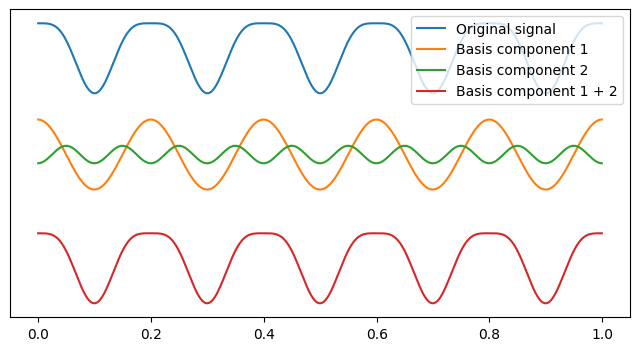

In [38]:
plt.figure(figsize=(8, 4), frameon=False)
plt.yticks([])
plt.plot(time_vect[:sample_rate], y[:sample_rate] + 3)
plt.plot(time_vect[:sample_rate], comp1[:sample_rate])
plt.plot(time_vect[:sample_rate], comp2[:sample_rate])
plt.plot(time_vect[:sample_rate], comp1[:sample_rate] + comp2[:sample_rate] - 3)
plt.legend(['Original signal', 'Basis component 1', 'Basis component 2', 'Basis component 1 + 2'])

The top signal in blue is our simulated signal, the orange and green signals are the two components identified by the Fourier transform coefficients which sum together to create the bottom signal in red.

It turns out that any signal can be represented by the summation of sets of simple sinusoids - even extremely non-linear or disjoint signals like triangular waves. This is a very powerful tool, but the need to include multiple high frequency components, known as harmonics, can create interpretation issues. In a complex or noisy signal, it might not be clear whether a peak in a power spectrum represents a harmonic of a low frequency signal or a stand-alone high frequency signal. The problem gets worse if we have several oscillations which are all creating separate harmonics. These signals may be untangled using more complicated analysis of the interactions between different Fourier components but these can get very complicated.

### Instantaneous Frequency
The Empirical Mode Decomposition offers a different perspective on this problem. Instead of representing dynamic signals with combinations of static basis functions, the EMD looks to isolate a small number of temporally adaptive basis functions and derive dynamics in frequency and amplitude directly from them.

These adaptive basis functions are called Intrinsic Mode Functions (IMFs) and are isolated from the data using the ‘sift’ algorithm. This is a time-domain algorithm which doesn’t require a Fourier transform to separate out different signals.

IMFs are defined by several features. They must be locally-symmetric around zero and contain the same number of extrema as zero-crossings (or differ by no more than 1). The ‘sift’ is a numerical algorithm for isolating signal components with exactly these features. Any residual after the sift is a non-oscillatory trend component.

Lets run a sift on our non-linear signal and plot the results.

<Axes: xlabel='Time (samples)'>

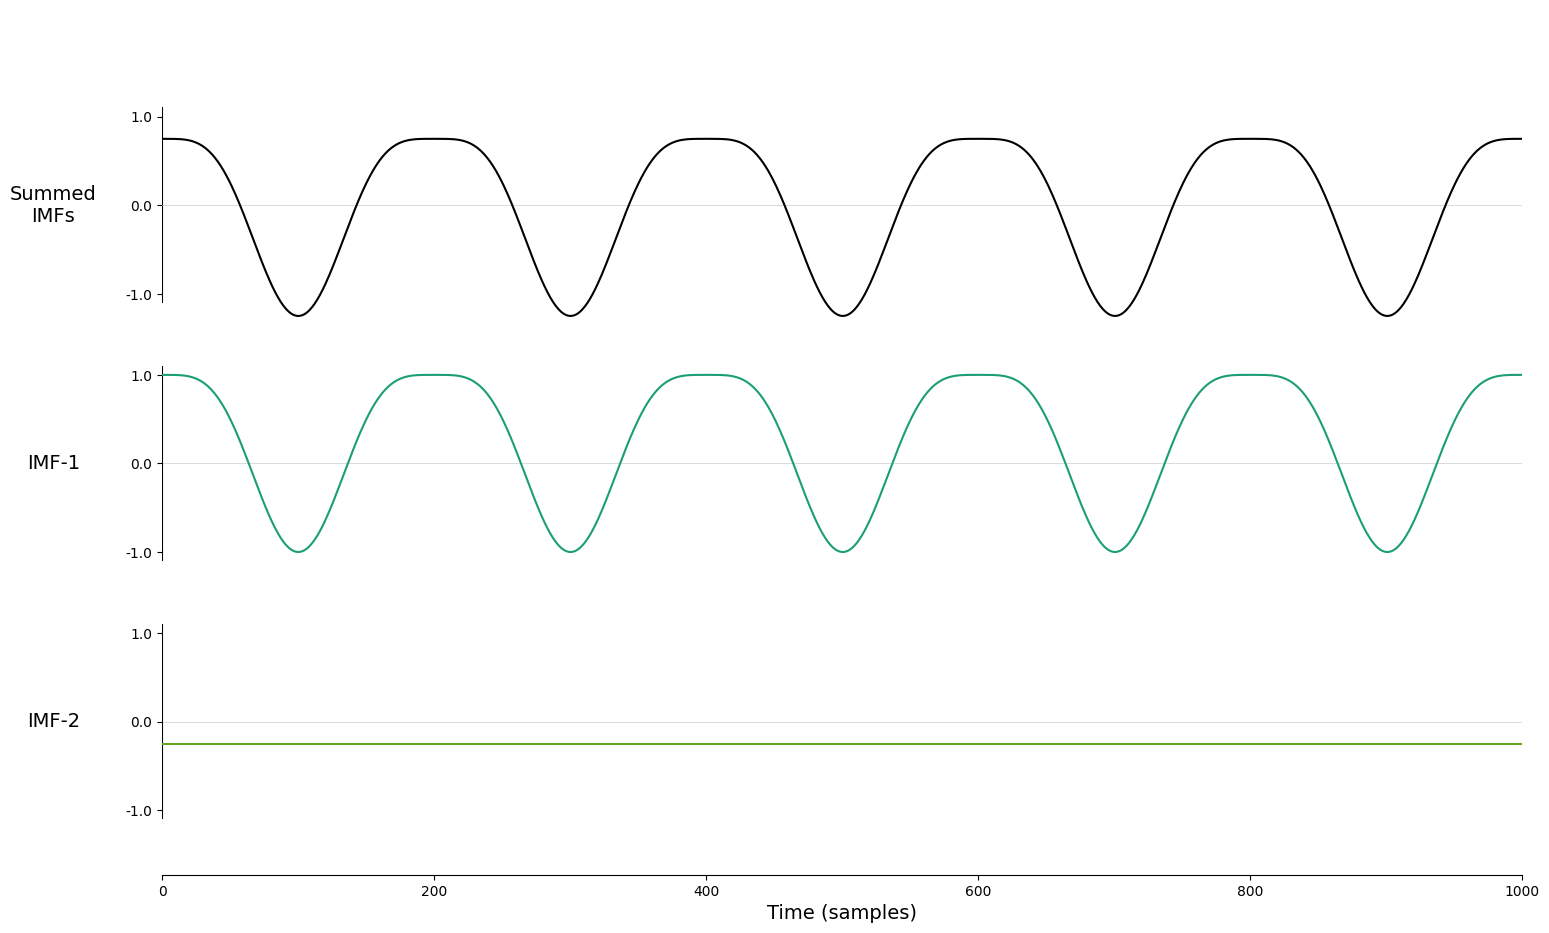

In [39]:
imf = emd.sift.sift(y)

emd.plotting.plot_imfs(imf[:sample_rate, :])

This dynamic representation of frequency is able to adapt to the changing waveform shape and describe the non-sinusoidal shape as a single smoothly varying component rather than as two separate, static components.

We can compute a power spectrum using these principles called the Hilbert-Huang transform

Text(0, 0.5, 'Power')

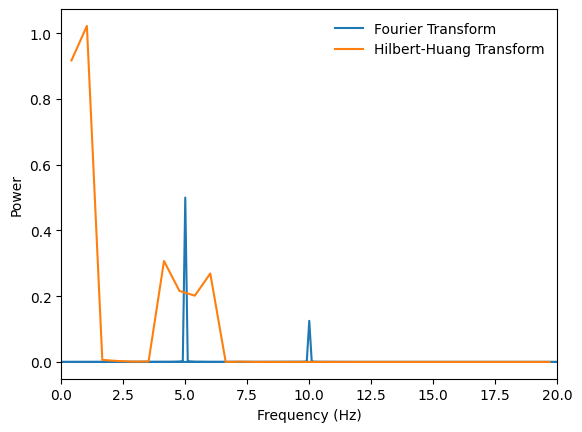

In [40]:
freq_range = (0.1, 20, 32)
hht_f, spec = emd.spectra.hilberthuang(IF, IA, freq_range, scaling='density')

plt.figure()
plt.plot(fft_f, np.abs(pyy))
plt.plot(hht_f, spec)
plt.legend(['Fourier Transform', 'Hilbert-Huang Transform'], frameon=False)
plt.xlim(0, 20)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')

The Hilbert-Huang transform gives a summary of the dynamic spectral content of the signal. It represents our non-linear signal as a distribution of frequencies around 5Hz without adding an additional signal component.

### Time-resolution
Finally, the instantaneous frequency and amplitude from the Hilbert transform allow us to see very rapid dynamics in oscillatory signals. Fourier methods are able to see dynamic changes by applying the transform in a sliding window but the choice of window size places an important constraint on the time-frequency resolution of the transform. Longer windows have greater frequency resolution as they are able to use a larger number of Fourier basis components - however these longer windows necessarily lead to worse time resolution.

In contrast, the instantaneous frequency stats naturally vary over time, so no window choice is required. Let’s take a closer look with a dynamic simulation.

In [41]:
# Create a signal with a dynamic oscillation
z = emd.simulate.ar_oscillator(25, sample_rate, seconds, r=0.975)[:, 0]

First we compute the sift, frequency transform and the Hilbert-Huang spectrum

In [42]:
imf = emd.sift.sift(z)
IP, IF, IA = emd.spectra.frequency_transform(imf, sample_rate, 'hilbert')

freq_range = (0.1, 50, 48)
hht_f, hht = emd.spectra.hilberthuang(IF, IA, freq_range, mode='amplitude', sum_time=False)
hht = ndimage.gaussian_filter(hht, 1)

Next, we compute a short-time Fourier-transform. The nperseg variable controls the window-length and time-frequency resolution. Higher values will lead to greater precision in frequency and worse precision in time.

In [43]:
nperseg = 2048
ftf, ftt, ftZ = signal.stft(z, nperseg=nperseg, fs=sample_rate, noverlap=nperseg-1)

Text(0, 0.5, 'Frequency (Hz)')

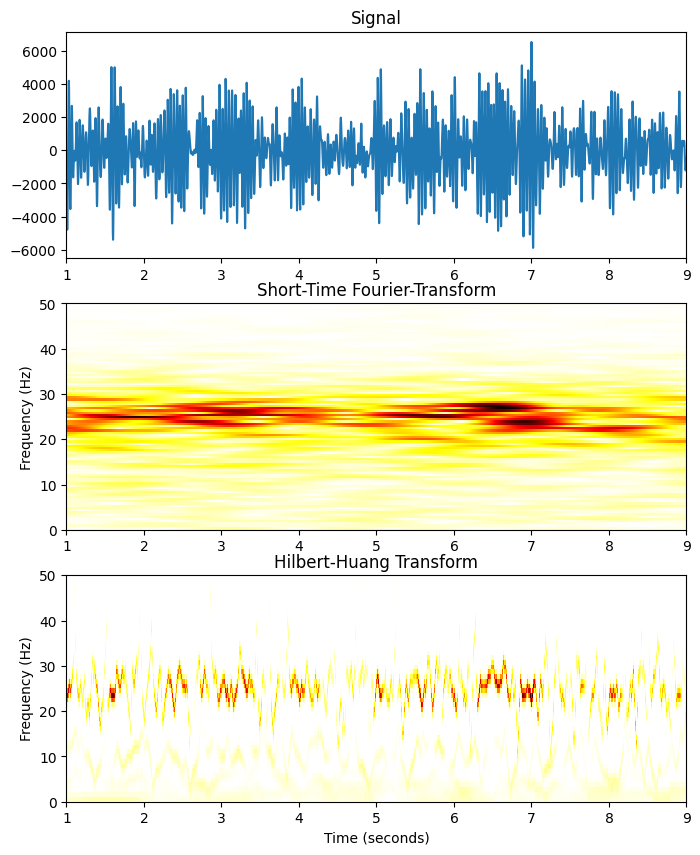

In [44]:
plt.figure(figsize=(8, 10))
plt.subplot(311)
plt.plot(time_vect, z)
plt.xlim(1, 9)
plt.title('Signal')
plt.subplot(312)
plt.pcolormesh(ftt, ftf, np.abs(ftZ), cmap='hot_r')
plt.ylim(0, 50)
plt.xlim(1, 9)
plt.title('Short-Time Fourier-Transform')
plt.ylabel('Frequency (Hz)')
plt.subplot(313)
plt.pcolormesh(time_vect, hht_f, hht, cmap='hot_r')
plt.ylim(0, 50)
plt.title('Hilbert-Huang Transform')
plt.xlim(1, 9)
plt.xlabel('Time (seconds)')
plt.ylabel('Frequency (Hz)')

Changes in oscillatory power are visible in both transforms but are noticeably smoother in the STFT compared to the HHT. The blur in the STFT is due to the windowing that we have applied, we can try to reduce this window size to increase the temporal resolution of our transform

In [45]:
nperseg = 512
ftf, ftt, ftZ = signal.stft(z, nperseg=nperseg, fs=sample_rate, noverlap=nperseg-1)  # r                         

Now we plot the two transforms together for another comparison.

Text(0, 0.5, 'Frequency (Hz)')

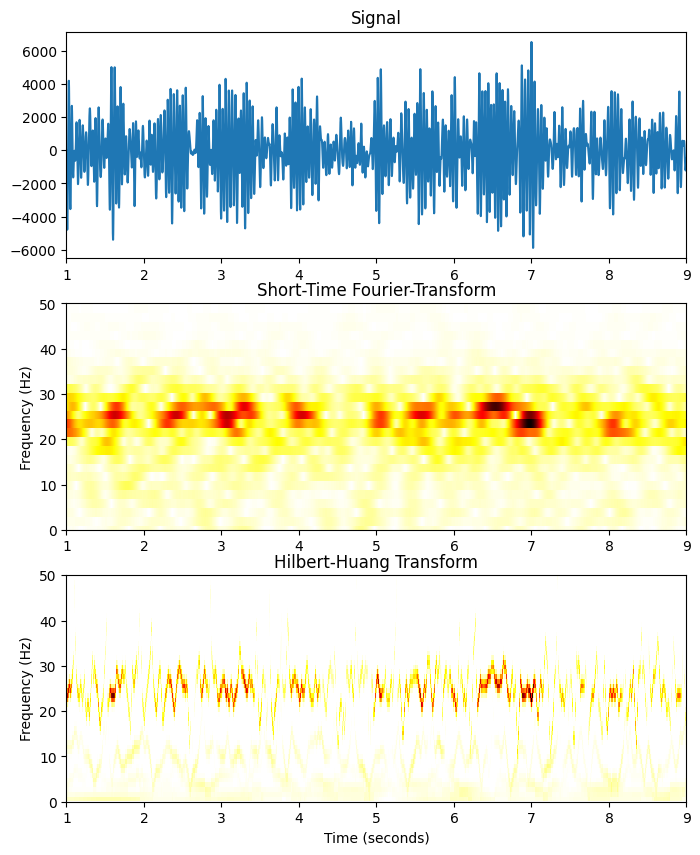

In [46]:
plt.figure(figsize=(8, 10))
plt.subplot(311)
plt.plot(time_vect, z)
plt.xlim(1, 9)
plt.title('Signal')
plt.subplot(312)
plt.pcolormesh(ftt, ftf, np.abs(ftZ), cmap='hot_r')
plt.ylim(0, 50)
plt.xlim(1, 9)
plt.title('Short-Time Fourier-Transform')
plt.ylabel('Frequency (Hz)')
plt.subplot(313)
plt.pcolormesh(time_vect, hht_f, hht, cmap='hot_r')
plt.ylim(0, 50)
plt.title('Hilbert-Huang Transform')
plt.xlim(1, 9)
plt.xlabel('Time (seconds)')
plt.ylabel('Frequency (Hz)')

Shortening the window-size in the STFT has reduced the temporal blur but increased the blur in the frequency dimension. The HHT produces a sharper image in both dimensions.

The remaining tutorials go into all of the above analysis in much more detail and try to introduce the motivations and concepts behind EMD alongside a range of practical examples. We also introduce some problems with the EMD and how to recognise & reduce them - there is no free-lunch in signal processing!

## Sifting

### Intro to the sift
This tutorial is a general introduction to the sift algorithm. We introduce the sift in steps and some of the options that can be tuned.

Lets make a simulated signal to get started. This is a fairly complicated signal with a non-linear 12Hz oscillation, a very slow fluctuation and some high frequency noise.

Number of samples: 1000
Signal shape: (1000,)


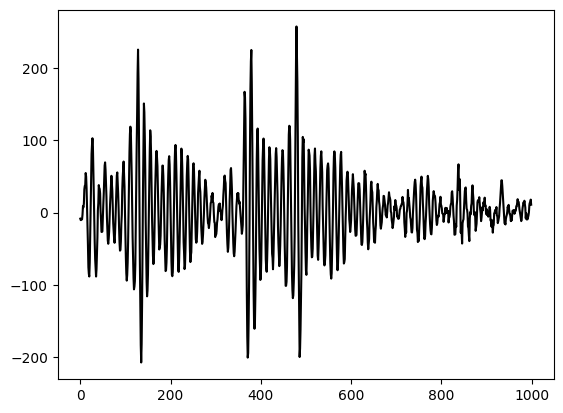

In [62]:
import emd
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt
from datasets import UORED

sample_rate = 42000
num_samples = 1000
time_vect = np.linspace(0, 10, num_samples)
print(f"Number of samples: {num_samples}")

dataset = UORED()
x = dataset.load_file("data/raw/uored/B_11_1.mat")[0][:num_samples]
print('Signal shape:', x.shape)
# freq = 
plt.figure()
plt.plot(x, 'k')

The sift works by iteratively extracting oscillatory components from a signal. Starting from the fastest and through to the very slowest until only a non-oscillatory trend is left. Each component is then known as an ‘Intrinsic Mode Function’ or IMF.

The extraction of these IMFs is a difficult problem without a clear analytic or symbolic solution. Therefore, the sift looks to iteratively approximate the best set of IMFs using a set of heuristic rules (this sort of analysis is a type of numerical algorithm).

The first thing the sift does is identify the very fastest dynamics in a signal. We do this by identifying all the peaks and troughs in the signal. Here, we do this with emd.sift.get_padded_extrema and plot the extrema on a segment of the signal.

(0.0, 500.0)

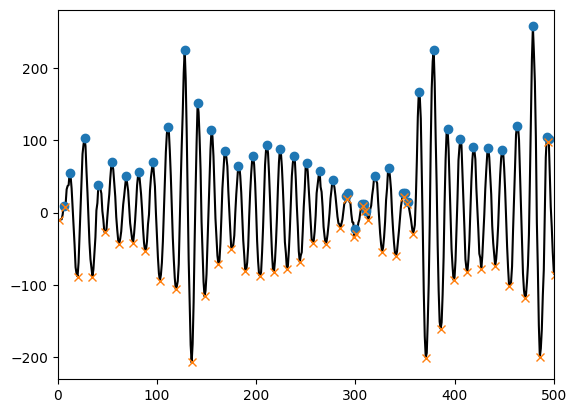

In [67]:
peak_locs, peak_mags = emd.sift.get_padded_extrema(x, pad_width=0, mode='peaks') # pega os máximos locais
trough_locs, trough_mags = emd.sift.get_padded_extrema(x, pad_width=0, mode='troughs') # pega os mínimos locais

plt.figure()
plt.plot(x, 'k')
plt.plot(peak_locs, peak_mags, 'o')
plt.plot(trough_locs, trough_mags, 'x')
plt.xlim(0, 500)

We want to extract the fastest dynamics from this signal - but what do we mean by fastest? We define the fastest dynamics to be the oscillations occurring between adjacent peaks and troughs in our signal - anything slower should be removed for now.

To isolate these fast dynamics, we identify an upper and lower amplitude envelope from the peaks and troughs and compute their average. Here we do this with emd.sift.interp_envelope (note: this uses emd.sift.get_padded_extrema internally to find the same extrema we plotted above) and then plot an example.

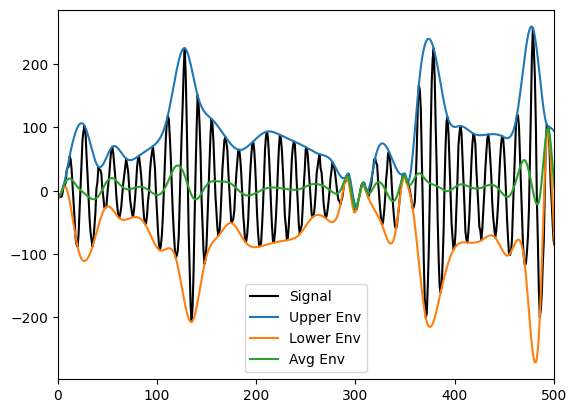

In [69]:
proto_imf = x.copy()
# Compute upper and lower envelopes
upper_env = emd.sift.interp_envelope(proto_imf, mode='upper')
lower_env = emd.sift.interp_envelope(proto_imf, mode='lower')

# Compute average envelope
avg_env = (upper_env+lower_env) / 2

plt.figure()
plt.plot(x, 'k')
plt.plot(upper_env)
plt.plot(lower_env)
plt.plot(avg_env)
plt.xlim(0, 500)
plt.legend(['Signal', 'Upper Env', 'Lower Env', 'Avg Env'])

In this segment, we can see that the fastest dynamics occur in the rapid oscillations of the black line between its upper a lower envelope. These oscillations are happening alongside dynamics on other time-scales which are all summed together to make the original signal. We approximate these slower dynamics through the average of the uppers and lower envelope - the green line in the plot above). The average envelope drifts more slowly than the fastest oscillations visible in the raw signal and tends to capture trends in the mean across several cycles of the fastest dynamics.

We can remove these slower components by simply subtracting this average envelope. Here we do this subtraction and make a quick plot

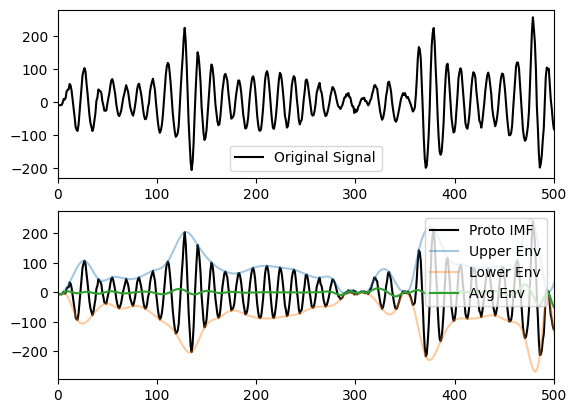

In [74]:
# Subtract slow dynamics from previous cell
proto_imf = x - avg_env

# Compute upper and lower envelopes
upper_env = emd.sift.interp_envelope(proto_imf, mode='upper')
lower_env = emd.sift.interp_envelope(proto_imf, mode='lower')

# Compute average envelope
avg_env = (upper_env+lower_env) / 2

plt.figure()
plt.subplot(211)
plt.plot(x, 'k')
plt.xlim(0, 500)
plt.legend(['Original Signal'])

plt.subplot(212)
plt.plot(proto_imf, 'k')
plt.plot(upper_env, alpha=.4)
plt.plot(lower_env, alpha=.4)
plt.plot(avg_env)
plt.xlim(0, 500)
plt.legend(['Proto IMF', 'Upper Env', 'Lower Env', 'Avg Env'])

The top panel shows the original signal and average envelope, and the bottom panel shows the signal with the average envelope removed and the envelopes of this new signal.

The fastest oscillations are now much clearer with the slow trends removed. The sift algorithm now just repeats these steps until certain stopping conditions are met. In general, we want to stop sifting an IMF once the average of the upper and lower envelopes are sufficiently close to zero. When this condition is met, it guarantees that the signal will behave well during analysis of instantaneous frequency (a story for another tutorial…).

Here we run another iteration of the sift on the residual of our previous one.

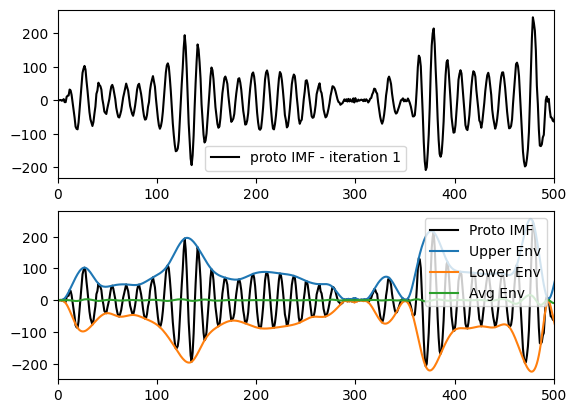

In [76]:
# Subtract slow dynamics from previous cell
proto_imf = proto_imf - avg_env

# Compute upper and lower envelopes
upper_env = emd.sift.interp_envelope(proto_imf, mode='upper')
lower_env = emd.sift.interp_envelope(proto_imf, mode='lower')

# Compute average envelope
avg_env = (upper_env+lower_env) / 2

plt.figure()
plt.subplot(211)
plt.plot(proto_imf, 'k')
plt.xlim(0, 500)
plt.legend(['proto IMF - iteration 1'])

plt.subplot(212)
plt.plot(proto_imf, 'k')
plt.plot(upper_env)
plt.plot(lower_env)
plt.plot(avg_env)
plt.xlim(0, 500)
plt.legend(['Proto IMF', 'Upper Env', 'Lower Env', 'Avg Env'])

After two iterations the average envelope is now very closer to zero though there are still some deviations. The full sift would continue iterating until we pass a defined threshold and accept the result as our IMF.

### Running sift iterations
We don’t want to run these iterations by hand, so lets define a function to do the work for us. Here, we make my_get_next_imf which will repeat the steps above until the average envelopes are sufficiently close to zero as defined by the sd_thresh. We will plot the sift ierations as we go and include an option to zoom in in part of the signal.

In [ ]:
def my_get_next_imf(x, zoom=None, sd_thresh=0.1):

    proto_imf = x.copy()  # Take a copy of the input so we don't overwrite anything
    continue_sift = True  # Define a flag indicating whether we should continue sifting
    niters = 0            # An iteration counter

    if zoom is None:
        zoom = (0, x.shape[0])

    # Main loop - we don't know how many iterations we'll need so we use a ``while`` loop
    while continue_sift:
        niters += 1  # Increment the counter

        # Compute upper and lower envelopes
        upper_env = emd.sift.interp_envelope(proto_imf, mode='upper')
        lower_env = emd.sift.interp_envelope(proto_imf, mode='lower')

        # Compute average envelope
        avg_env = (upper_env+lower_env) / 2

        # Add a summary subplot
        plt.subplot(5, 1, niters)
        plt.plot(proto_imf[zoom[0]:zoom[1]], 'k')
        plt.plot(upper_env[zoom[0]:zoom[1]])
        plt.plot(lower_env[zoom[0]:zoom[1]])
        plt.plot(avg_env[zoom[0]:zoom[1]])

        # Should we stop sifting?
        stop, val = emd.sift.stop_imf_sd(proto_imf-avg_env, proto_imf, sd=sd_thresh) # sd o valor limite (threshold) de desvio padrão normalizado para decidir se o modo estabilizou.

        # Remove envelope from proto IMF
        proto_imf = proto_imf - avg_env

        # and finally, stop if we're stopping
        if stop:
            continue_sift = False

    # Return extracted IMF
    return proto_imf

The core parts of this function should be familiar from earlier parts of the tutorial. We can now call this function to find the fastest IMF from our signal.

Let’s extract our IMF, plotting the iterations and zooming in to a 100 sample period so we can see the details.

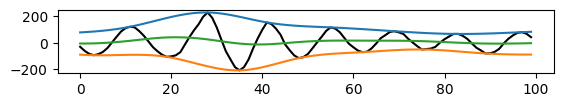

In [78]:
imf1 = my_get_next_imf(x, zoom=(100, 200))

The top panel shows the original signal and each lower panel shows successive iterations. The first iteration removes the majority of the slow oscillation whilst the second does some fine-tuning.

Here we plot the original signal, the first IMF and the residual after subtracting the first IMF from the signal.

([], [])

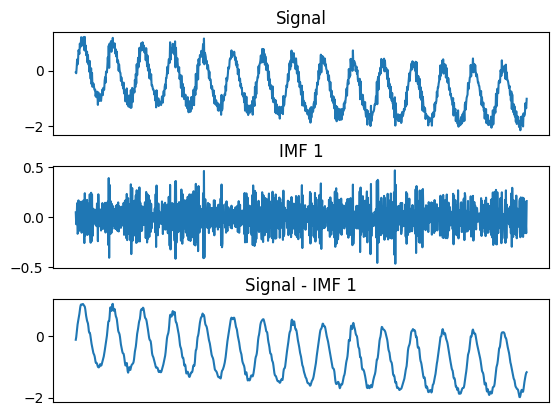

In [54]:
plt.figure()
plt.subplots_adjust(hspace=0.3)

plt.subplot(311)
plt.plot(x)
plt.title('Signal')
plt.xticks([])

plt.subplot(312)
plt.plot(imf1)
plt.title('IMF 1')
plt.xticks([])

plt.subplot(313)
plt.plot(x - imf1)
plt.title('Signal - IMF 1')
plt.xticks([])